# 02 — K-Means Independiente por Régimen

---
**Prerrequisito:** `01_preprocessing_feature_engineering.ipynb`

- Segmentación por régimen (PreTec21 / Tec21)
- K-Means **independiente** por régimen + selección K óptimo (codo, Silhouette, DB)
- Match de clusters entre regímenes por distancia coseno

Guarda en `data/processed/`: `df_pre.csv`, `df_tec.csv`, `df_match.csv` (DataFrames),
más modelos KMeans y scalers en pickle.


## Setup e Importaciones

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pickle
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial.distance import cosine as cosine_dist

from sklearn.cluster       import KMeans
from sklearn.metrics       import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

SEED = 42
np.random.seed(SEED)
print('Librerías cargadas')

✓ Librerías cargadas


## Configuración

In [2]:
PROCESSED_DIR = Path('../../data/processed')
IMG_DIR       = Path('images'); IMG_DIR.mkdir(exist_ok=True)

PRETEC21_GENS  = ['AD14', 'AD15', 'AD16', 'AD17', 'AD18']
TEC21_GENS     = ['AD19', 'AD20']
TARGET         = 'retention'
K_CLUSTERS     = 4
MIN_SILHOUETTE = 0.30
MAX_DB         = 1.50
MATCH_HIGH     = 0.15
MATCH_PARTIAL  = 0.35

K_CLUSTERS: 4
NOTA: K-Means se entrena INDEPENDIENTEMENTE en cada régimen.


## Carga del Dataset Procesado

In [3]:
df = pd.read_csv(PROCESSED_DIR / 'df_preprocessed.csv')

✓ df cargado  →  (77517, 29)
Generaciones: ['AD14', 'AD15', 'AD16', 'AD17', 'AD18', 'AD19', 'AD20']


## Segmentación por Régimen

In [4]:
df_pre = df[df['generation'].isin(PRETEC21_GENS)].copy().reset_index(drop=True)
df_tec = df[df['generation'].isin(TEC21_GENS)].copy().reset_index(drop=True)

print(f'PreTec21 (AD14-AD18): {len(df_pre):,} estudiantes  |  Deserción: {(df_pre[TARGET]==0).mean()*100:.1f}%')
print(f'Tec21    (AD19-AD20): {len(df_tec):,} estudiantes  |  Deserción: {(df_tec[TARGET]==0).mean()*100:.1f}%')

PreTec21 (AD14-AD18): 53,010 estudiantes  |  Deserción: 8.8%
Tec21    (AD19-AD20): 24,507 estudiantes  |  Deserción: 8.7%


## K-Means INDEPENDIENTE por Régimen

Cada modelo encuentra los clusters óptimos dentro de su propia distribución,
sin heredar la geometría del otro régimen.

In [5]:
CLUSTER_COLS_CANDIDATES = [
    'PNA', 'admission_test_norm', 'english.evaluation', 'admission.rubric',
    'apoyo_financiero', 'has_extracurriculars', 'first_gen_enc',
    'educ_padres_max', 'FTE', 'age',
]
CLUSTER_COLS = [c for c in CLUSTER_COLS_CANDIDATES if c in df.columns]
print(f'Variables de clustering ({len(CLUSTER_COLS)}): {CLUSTER_COLS}')

Variables de clustering (10): ['PNA', 'admission_test_norm', 'english.evaluation', 'admission.rubric', 'apoyo_financiero', 'has_extracurriculars', 'first_gen_enc', 'educ_padres_max', 'FTE', 'age']


## Selección de K Óptimo (Codo + Silhouette + Davies-Bouldin)

--- PreTec21 ---
  PreTec21  k=2  inertia=  43,181  sil=0.145  DB=2.265
  PreTec21  k=3  inertia=  37,474  sil=0.165  DB=1.788
  PreTec21  k=4  inertia=  33,682  sil=0.179  DB=1.683
  PreTec21  k=5  inertia=  30,641  sil=0.169  DB=1.653
  PreTec21  k=6  inertia=  28,758  sil=0.173  DB=1.580
  PreTec21  k=7  inertia=  27,300  sil=0.156  DB=1.627
  PreTec21  k=8  inertia=  26,086  sil=0.162  DB=1.651
   k óptimo por Silhouette: 4  |  por DB: 6

---Tec21 ---
  Tec21  k=2  inertia=  43,282  sil=0.318  DB=1.459
  Tec21  k=3  inertia=  37,422  sil=0.194  DB=1.738
  Tec21  k=4  inertia=  32,570  sil=0.201  DB=1.364
  Tec21  k=5  inertia=  30,049  sil=0.198  DB=1.492
  Tec21  k=6  inertia=  27,398  sil=0.209  DB=1.322
  Tec21  k=7  inertia=  25,968  sil=0.192  DB=1.417
  Tec21  k=8  inertia=  24,107  sil=0.195  DB=1.326
   k óptimo por Silhouette: 2  |  por DB: 6


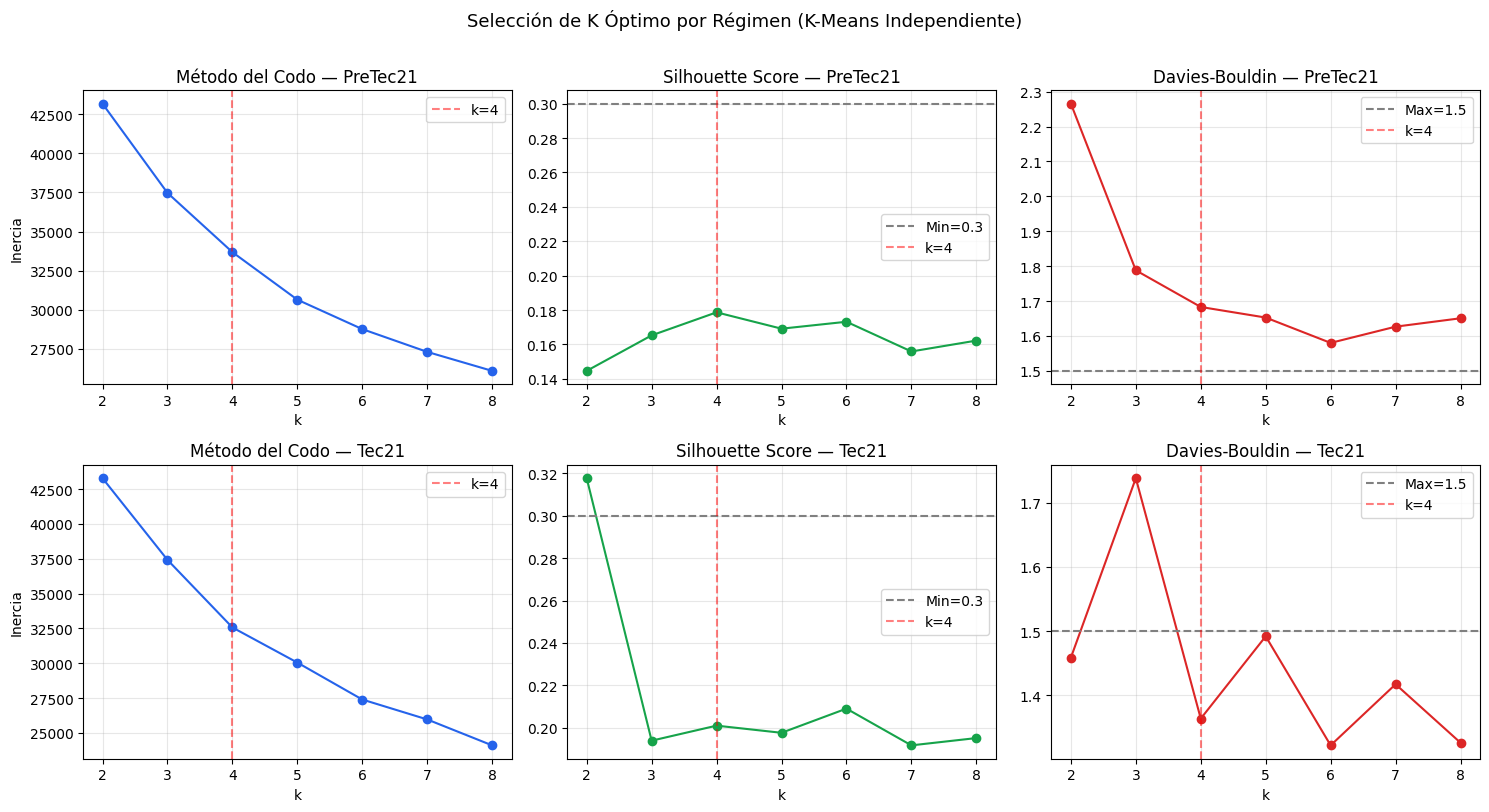

K configurado: 4


In [15]:
K_RANGE     = range(2, 9)
SAMPLE_SIZE = 5000

def select_k(X_scaled, regime_name):
    idx = np.random.choice(len(X_scaled), min(SAMPLE_SIZE, len(X_scaled)), replace=False)
    X_s = X_scaled[idx]
    inertias, sils, dbs = [], [], []
    for k in K_RANGE:
        km_tmp = KMeans(n_clusters=k, n_init=10, random_state=SEED)
        lab    = km_tmp.fit_predict(X_s)
        inertias.append(km_tmp.inertia_)
        sils.append(silhouette_score(X_s, lab))
        dbs.append(davies_bouldin_score(X_s, lab))
        print(f'  {regime_name}  k={k}  inertia={km_tmp.inertia_:>8,.0f}'
              f'  sil={sils[-1]:.3f}  DB={dbs[-1]:.3f}')
    best_sil_k = list(K_RANGE)[int(np.argmax(sils))]
    best_db_k  = list(K_RANGE)[int(np.argmin(dbs))]
    print(f'   k óptimo por Silhouette: {best_sil_k}  |  por DB: {best_db_k}')
    return inertias, sils, dbs

X_pre_df_tmp = df_pre[CLUSTER_COLS].copy().fillna(df_pre[CLUSTER_COLS].median())
X_tec_df_tmp = df_tec[CLUSTER_COLS].copy().fillna(df_tec[CLUSTER_COLS].median())
Xp_tmp = StandardScaler().fit_transform(X_pre_df_tmp.values.astype(float))
Xt_tmp = StandardScaler().fit_transform(X_tec_df_tmp.values.astype(float))

print('--- PreTec21 ---')
iner_pre, sil_pre_ks, db_pre_ks = select_k(Xp_tmp, 'PreTec21')
print()
print('---Tec21 ---')
iner_tec, sil_tec_ks, db_tec_ks = select_k(Xt_tmp, 'Tec21')

# Visualización
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
ks = list(K_RANGE)
for row, (name, inertias, sils, dbs) in enumerate([
    ('PreTec21', iner_pre, sil_pre_ks, db_pre_ks),
    ('Tec21',    iner_tec, sil_tec_ks, db_tec_ks)
]):
    axes[row,0].plot(ks, inertias, 'o-', color='#2563eb')
    axes[row,0].axvline(K_CLUSTERS, ls='--', color='red', alpha=0.5, label=f'k={K_CLUSTERS}')
    axes[row,0].set_title(f'Método del Codo — {name}')
    axes[row,0].set_xlabel('k'); axes[row,0].set_ylabel('Inercia')
    axes[row,0].legend(); axes[row,0].grid(alpha=0.3)

    axes[row,1].plot(ks, sils, 'o-', color='#16a34a')
    axes[row,1].axhline(MIN_SILHOUETTE, ls='--', color='gray', label=f'Min={MIN_SILHOUETTE}')
    axes[row,1].axvline(K_CLUSTERS, ls='--', color='red', alpha=0.5, label=f'k={K_CLUSTERS}')
    axes[row,1].set_title(f'Silhouette Score — {name}')
    axes[row,1].set_xlabel('k'); axes[row,1].legend(); axes[row,1].grid(alpha=0.3)

    axes[row,2].plot(ks, dbs, 'o-', color='#dc2626')
    axes[row,2].axhline(MAX_DB, ls='--', color='gray', label=f'Max={MAX_DB}')
    axes[row,2].axvline(K_CLUSTERS, ls='--', color='red', alpha=0.5, label=f'k={K_CLUSTERS}')
    axes[row,2].set_title(f'Davies-Bouldin — {name}')
    axes[row,2].set_xlabel('k'); axes[row,2].legend(); axes[row,2].grid(alpha=0.3)

plt.suptitle('Selección de K Óptimo por Régimen (K-Means Independiente)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(IMG_DIR / 'k_selection_independiente.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'K configurado: {K_CLUSTERS}')

### K-Means PreTec21

In [17]:
X_pre_df = df_pre[CLUSTER_COLS].copy()
X_pre_df.fillna(X_pre_df.median(), inplace=True)

scaler_pre = StandardScaler()
Xp_scaled  = scaler_pre.fit_transform(X_pre_df.values.astype(float))

km_pre = KMeans(n_clusters=K_CLUSTERS, n_init=20, random_state=SEED)
km_pre.fit(Xp_scaled)
df_pre['cluster'] = km_pre.labels_

sil_pre = silhouette_score(Xp_scaled, km_pre.labels_)
db_pre  = davies_bouldin_score(Xp_scaled, km_pre.labels_)
print(f'PreTec21  Silhouette={sil_pre:.3f}  DB={db_pre:.3f}')


PreTec21  Silhouette=0.177  DB=1.683


### K-Means Tec21 

In [18]:
X_tec_df = df_tec[CLUSTER_COLS].copy()
X_tec_df.fillna(X_tec_df.median(), inplace=True)

scaler_tec = StandardScaler()
Xt_scaled  = scaler_tec.fit_transform(X_tec_df.values.astype(float))

km_tec = KMeans(n_clusters=K_CLUSTERS, n_init=20, random_state=SEED)
km_tec.fit(Xt_scaled)
df_tec['cluster'] = km_tec.labels_

sil_tec = silhouette_score(Xt_scaled, km_tec.labels_)
db_tec  = davies_bouldin_score(Xt_scaled, km_tec.labels_)
print(f'Tec21 Silhouette={sil_tec:.3f}  DB={db_tec:.3f}')

Tec21 Silhouette=0.204  DB=1.361


### Perfiles de clusters

In [19]:
def cluster_profile(df_regime, regime_name):
    stats = (df_regime.groupby('cluster')
             .agg(n=(TARGET,'count'),
                  tasa_desercion=(TARGET, lambda x: (x==0).mean()))
             .round(3))
    stats['pct_total'] = (stats['n'] / len(df_regime) * 100).round(1)
    print(f'\n--- Perfiles {regime_name} (K-Means independiente) ---')
    print(stats.sort_values('tasa_desercion', ascending=False).to_string())
    return stats

stats_pre = cluster_profile(df_pre, 'PreTec21')
stats_tec = cluster_profile(df_tec, 'Tec21')


--- Perfiles PreTec21 (K-Means independiente) ---
             n  tasa_desercion  pct_total
cluster                                  
1        21311           0.122       40.2
3         2644           0.109        5.0
0         9498           0.070       17.9
2        19557           0.058       36.9

--- Perfiles Tec21 (K-Means independiente) ---
             n  tasa_desercion  pct_total
cluster                                  
2          110           0.745        0.4
3         3110           0.126       12.7
1        11888           0.104       48.5
0         9399           0.045       38.4


In [20]:
print('--- Medias por cluster (PreTec21) ---')
for c in sorted(df_pre['cluster'].unique()):
    sub = df_pre[df_pre['cluster']==c]
    print(f'\nCluster {c} | n={len(sub):,} | dropout={(sub[TARGET]==0).mean():.3f}')
    for col in CLUSTER_COLS:
        print(f'  {col:<30} {sub[col].mean():.4f}')

--- Medias por cluster (PreTec21) ---

Cluster 0 | n=9,498 | dropout=0.070
  PNA                            88.3670
  admission_test_norm            0.8122
  english.evaluation             5.9863
  admission.rubric               36.7096
  apoyo_financiero               0.2425
  has_extracurriculars           0.9997
  first_gen_enc                  0.0000
  educ_padres_max                1.4315
  FTE                            1.0520
  age                            18.2118

Cluster 1 | n=21,311 | dropout=0.122
  PNA                            83.2023
  admission_test_norm            0.7604
  english.evaluation             4.5344
  admission.rubric               29.4425
  apoyo_financiero               0.0980
  has_extracurriculars           0.0121
  first_gen_enc                  0.0000
  educ_padres_max                1.3259
  FTE                            1.0514
  age                            18.1603

Cluster 2 | n=19,557 | dropout=0.058
  PNA                            91.3155
  

In [21]:
print('--- Medias por cluster (Tec21) ---')
for c in sorted(df_tec['cluster'].unique()):
    sub = df_tec[df_tec['cluster']==c]
    print(f'\nCluster {c} | n={len(sub):,} | dropout={(sub[TARGET]==0).mean():.3f}')
    for col in CLUSTER_COLS:
        print(f'  {col:<30} {sub[col].mean():.4f}')

--- Medias por cluster (Tec21) ---

Cluster 0 | n=9,399 | dropout=0.045
  PNA                            92.4198
  admission_test_norm            0.8397
  english.evaluation             5.5922
  admission.rubric               38.9398
  apoyo_financiero               0.4756
  has_extracurriculars           1.0000
  first_gen_enc                  0.0000
  educ_padres_max                1.4392
  FTE                            0.9832
  age                            18.0288

Cluster 1 | n=11,888 | dropout=0.104
  PNA                            84.6652
  admission_test_norm            0.7386
  english.evaluation             5.3869
  admission.rubric               35.0168
  apoyo_financiero               0.0495
  has_extracurriculars           1.0000
  first_gen_enc                  0.0001
  educ_padres_max                1.4266
  FTE                            0.9652
  age                            18.2884

Cluster 2 | n=110 | dropout=0.745
  PNA                            87.9741
  admiss

### PCA 2D — visualización de clusters

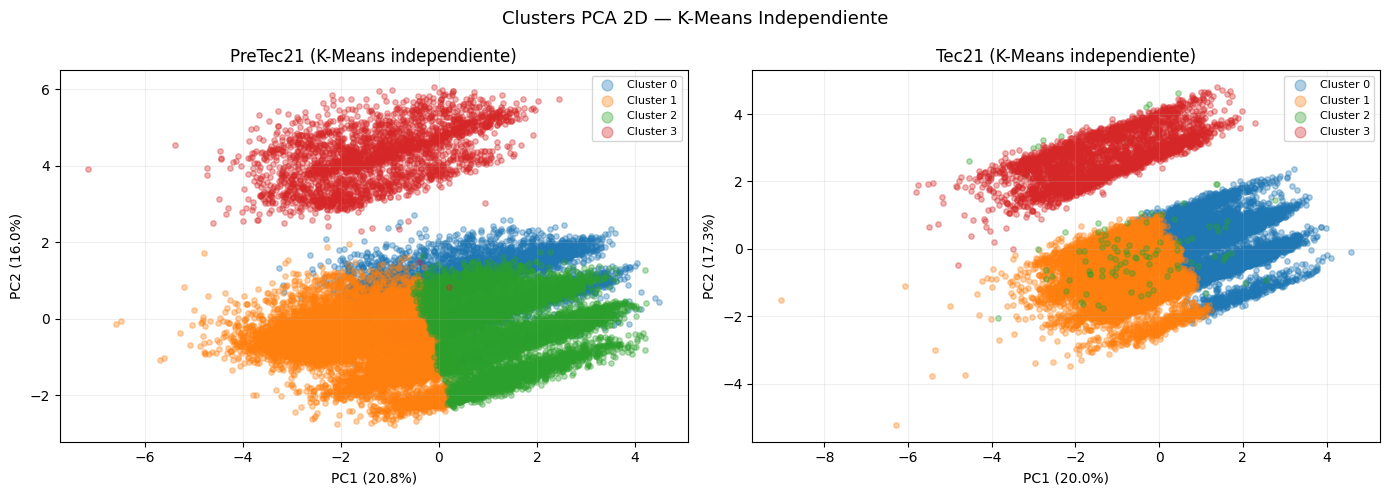

In [22]:
pca_pre = PCA(n_components=2, random_state=SEED).fit(Xp_scaled)
pca_tec = PCA(n_components=2, random_state=SEED).fit(Xt_scaled)
Zp = pca_pre.transform(Xp_scaled)
Zt = pca_tec.transform(Xt_scaled)

COLORS = plt.cm.tab10.colors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, Z, labels, pca_obj, ax in [
    ('PreTec21', Zp, km_pre.labels_, pca_pre, axes[0]),
    ('Tec21',    Zt, km_tec.labels_, pca_tec, axes[1])
]:
    for k in range(K_CLUSTERS):
        mask = labels == k
        ax.scatter(Z[mask,0], Z[mask,1], s=15, alpha=0.35, color=COLORS[k], label=f'Cluster {k}')
    ax.set_title(f'{name} (K-Means independiente)')
    ax.set_xlabel(f'PC1 ({pca_obj.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca_obj.explained_variance_ratio_[1]*100:.1f}%)')
    ax.legend(markerscale=2, fontsize=8); ax.grid(alpha=0.2)

plt.suptitle('Clusters PCA 2D — K-Means Independiente', fontsize=13)
plt.tight_layout()
plt.savefig(IMG_DIR / 'clusters_pca_independiente.png', dpi=150, bbox_inches='tight')
plt.show()


##  Match de Clusters entre Regímenes

Los IDs de cluster no son directamente comparables: se calcula la **distancia coseno**
entre centroides estandarizados.
- < 0.15 → **Match alto**
- 0.15–0.35 → **Match parcial**
- > 0.35 → **Sin match**

Matriz de distancias coseno:
        Tec_C0  Tec_C1  Tec_C2  Tec_C3
Pre_C0  0.7940  0.9986  1.9374  1.1262
Pre_C1  1.7867  0.2473  0.6074  1.0115
Pre_C2  0.1415  1.6264  0.6293  1.3827
Pre_C3  1.3166  1.3797  1.1716  0.0299

--- Resultado del Match ---
Pre_C0 -> Tec_C0  |  dist=0.7940  |  SIN MATCH
  PreTec21: n=9,498  dropout=0.070
  Tec21:    n=9,399  dropout=0.045
Pre_C1 -> Tec_C1  |  dist=0.2473  |  PARCIAL
  PreTec21: n=21,311  dropout=0.122
  Tec21:    n=11,888  dropout=0.104
Pre_C2 -> Tec_C0  |  dist=0.1415  |  ALTO
  PreTec21: n=19,557  dropout=0.058
  Tec21:    n=9,399  dropout=0.045
Pre_C3 -> Tec_C3  |  dist=0.0299  |  ALTO
  PreTec21: n=2,644  dropout=0.109
  Tec21:    n=3,110  dropout=0.126


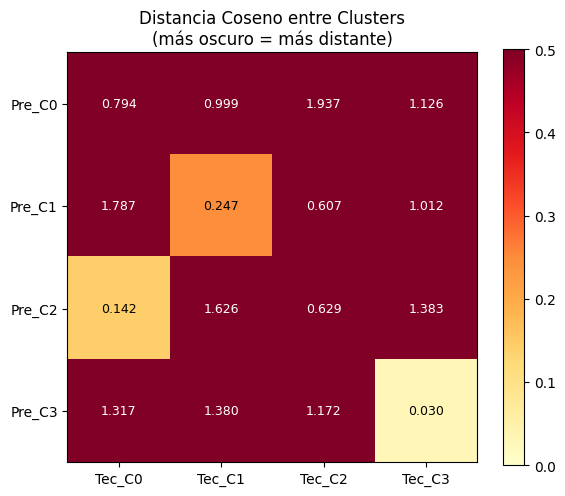

In [23]:
centroids_pre = km_pre.cluster_centers_
centroids_tec = km_tec.cluster_centers_

dist_matrix = np.zeros((K_CLUSTERS, K_CLUSTERS))
for i in range(K_CLUSTERS):
    for j in range(K_CLUSTERS):
        dist_matrix[i, j] = cosine_dist(centroids_pre[i], centroids_tec[j])

df_dist = pd.DataFrame(dist_matrix,
                       index=[f'Pre_C{i}' for i in range(K_CLUSTERS)],
                       columns=[f'Tec_C{j}' for j in range(K_CLUSTERS)])
print('Matriz de distancias coseno:')
print(df_dist.round(4).to_string())

print('\n--- Resultado del Match ---')
match_results = []
for i in range(K_CLUSTERS):
    j_best = int(np.argmin(dist_matrix[i]))
    d_best = dist_matrix[i, j_best]
    quality = 'ALTO' if d_best < MATCH_HIGH else ('PARCIAL' if d_best < MATCH_PARTIAL else 'SIN MATCH')
    n_pre  = (df_pre['cluster']==i).sum()
    n_tec  = (df_tec['cluster']==j_best).sum()
    dr_pre = (df_pre[df_pre['cluster']==i][TARGET]==0).mean()
    dr_tec = (df_tec[df_tec['cluster']==j_best][TARGET]==0).mean()
    match_results.append({
        'Pre_Cluster': i, 'Tec_Cluster': j_best,
        'Cosine_dist': round(d_best,4), 'Match': quality,
        'n_Pre': n_pre, 'n_Tec': n_tec,
        'dropout_Pre': round(dr_pre,3), 'dropout_Tec': round(dr_tec,3)
    })
    print(f'Pre_C{i} -> Tec_C{j_best}  |  dist={d_best:.4f}  |  {quality}')
    print(f'  PreTec21: n={n_pre:,}  dropout={dr_pre:.3f}')
    print(f'  Tec21:    n={n_tec:,}  dropout={dr_tec:.3f}')

df_match = pd.DataFrame(match_results)

# Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(dist_matrix, cmap='YlOrRd', vmin=0, vmax=0.5)
ax.set_xticks(range(K_CLUSTERS)); ax.set_xticklabels([f'Tec_C{j}' for j in range(K_CLUSTERS)])
ax.set_yticks(range(K_CLUSTERS)); ax.set_yticklabels([f'Pre_C{i}' for i in range(K_CLUSTERS)])
for i in range(K_CLUSTERS):
    for j in range(K_CLUSTERS):
        ax.text(j, i, f'{dist_matrix[i,j]:.3f}', ha='center', va='center', fontsize=9,
                color='white' if dist_matrix[i,j] > 0.25 else 'black')
plt.colorbar(im, ax=ax)
ax.set_title('Distancia Coseno entre Clusters\n(más oscuro = más distante)')
plt.tight_layout()
plt.savefig(IMG_DIR / 'match_distance_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## Guardar artefactos

In [24]:
import json

# DataFrames a CSV 
df_pre.to_csv(PROCESSED_DIR / 'df_pre.csv', index=False)
df_tec.to_csv(PROCESSED_DIR / 'df_tec.csv', index=False)
df_match.to_csv(PROCESSED_DIR / 'df_match.csv', index=False)

# Lista de columnas a JSON 
with open(PROCESSED_DIR / 'cluster_cols.json', 'w') as f:
    json.dump(CLUSTER_COLS, f)

# Modelos sklearn a pickle (no tienen equivalente CSV) 
for fname, obj in [('km_pre.pkl', km_pre), ('km_tec.pkl', km_tec),
                   ('scaler_pre.pkl', scaler_pre), ('scaler_tec.pkl', scaler_tec)]:
    with open(PROCESSED_DIR / fname, 'wb') as f:
        pickle.dump(obj, f)

# Arrays numpy
np.save(PROCESSED_DIR / 'Xp_scaled.npy', Xp_scaled)
np.save(PROCESSED_DIR / 'Xt_scaled.npy', Xt_scaled)

print(f'\nSilhouette  PreTec21={sil_pre:.3f}  Tec21={sil_tec:.3f}')
print(f'DB          PreTec21={db_pre:.3f}  Tec21={db_tec:.3f}')


Silhouette  PreTec21=0.177  Tec21=0.204
DB          PreTec21=1.683  Tec21=1.361
